# 5. Detrending -- Soja no Parana

O notebook equivalente do pipeline de milho (`5. Detrending.ipynb`) estava incompleto no
repositorio original (so demonstrava o agrupamento por ano para 1 municipio de exemplo,
sem chegar a calcular `beta_0`/`beta_1` nem gravar o resultado). Esta versao completa o
fluxo, usando **regressao linear simples** (`yield ~ ano`) por municipio -- a abordagem
padrao para remover a tendencia tecnologica (melhoria genetica, manejo, etc.) e isolar a
variabilidade de produtividade explicada pelo clima, que e o alvo que o WOFOST tenta
reproduzir na etapa de calibracao (7. Optimization).

Para cada `point_id_<cod>.nc`:
1. le a serie anual de `yield` (produtividade IBGE) ja embutida no arquivo (etapa 3);
2. ajusta `yield = beta_0 + beta_1 * ano` por minimos quadrados;
3. calcula a produtividade destendenciada, ancorada no ultimo ano da serie (`ano_ref`):
   `dyield(ano) = yield_obs(ano) - (beta_0 + beta_1*ano) + (beta_0 + beta_1*ano_ref)`;
4. grava `dyield` como nova variavel no NetCDF, com `beta_0`/`beta_1` como atributos --
   exatamente o formato que `NetCDFDataLoader.get_point_info` espera
   (`ds.variables['dyield'].attrs['beta_0'/'beta_1']`).

Municipios com menos de 3 safras validas nao tem tendencia suficientemente confiavel para
ajustar uma reta: `dyield` fica igual a `yield` bruto nesses casos (`beta_1=0`).


In [1]:
import glob
import os
import sys

import numpy as np
import pandas as pd
import xarray as xr
from tqdm import tqdm

sys.path.append(os.path.join(os.getcwd(), 'util'))
from util.utils_soja_pr import setup_paths_soja_pr

paths = setup_paths_soja_pr()

MIN_ANOS_PARA_TENDENCIA = 3

arquivos_nc = glob.glob(os.path.join(paths['COMPLETO'], "point_id_*.nc"))
print(f"Total de arquivos: {len(arquivos_nc)}")


Total de arquivos: 392


In [2]:
def detrend_point(arquivo):
    with xr.open_dataset(arquivo) as ds:
        ds_loaded = ds.load()

    anos = ds_loaded['ano_safra'].values
    yields = ds_loaded['yield'].values

    df_anual = (
        pd.DataFrame({'ano': anos, 'yield': yields})
        .dropna()
        .drop_duplicates(subset='ano')
        .sort_values('ano')
    )

    if len(df_anual) == 0:
        ds_loaded.close()
        return None, 0

    if len(df_anual) >= MIN_ANOS_PARA_TENDENCIA:
        beta_1, beta_0 = np.polyfit(df_anual['ano'], df_anual['yield'], 1)
    else:
        beta_1, beta_0 = 0.0, float(df_anual['yield'].mean())

    ano_ref = df_anual['ano'].max()
    nivel_ref = beta_0 + beta_1 * ano_ref

    yield_by_year = df_anual.set_index('ano')['yield'].to_dict()
    dyield_by_year = {
        ano: (yld - (beta_0 + beta_1 * ano) + nivel_ref)
        for ano, yld in yield_by_year.items()
    }

    dyield_arr = np.array([dyield_by_year.get(a, np.nan) for a in anos], dtype=float)

    ds_loaded['dyield'] = ('date', dyield_arr)
    ds_loaded['dyield'].attrs['beta_0'] = float(beta_0)
    ds_loaded['dyield'].attrs['beta_1'] = float(beta_1)
    ds_loaded['dyield'].attrs['ano_referencia'] = int(ano_ref)
    ds_loaded['dyield'].attrs['n_anos'] = len(df_anual)

    tmp_path = arquivo + '.tmp'
    ds_loaded.to_netcdf(tmp_path)
    ds_loaded.close()
    os.replace(tmp_path, arquivo)

    return (beta_0, beta_1), len(df_anual)


In [4]:
arquivos_nc[0]

'd:\\_py\\AgroIA_prod\\inputs\\data\\soja_pr\\completo\\point_id_4100103.nc'

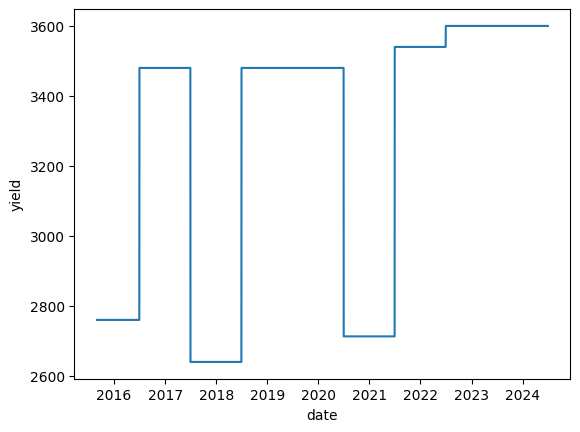

In [ ]:
ds_loaded = xr.open_dataset(arquivos_nc[0]).load()


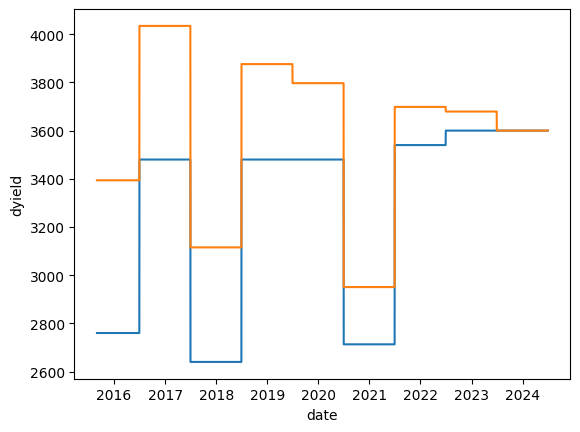

In [8]:
ds_loaded['yield'].plot();ds_loaded['dyield'].plot()

In [3]:
resumo = []
for arquivo in tqdm(arquivos_nc, desc="Destendenciando"):
    ponto_id = os.path.basename(arquivo).replace('point_id_', '').replace('.nc', '')
    try:
        coefs, n_anos = detrend_point(arquivo)
        if coefs is None:
            print(f"[pulado] {ponto_id}: sem nenhum ano de yield valido.")
            continue
        beta_0, beta_1 = coefs
        resumo.append({'point_id': ponto_id, 'beta_0': beta_0, 'beta_1': beta_1, 'n_anos': n_anos})
    except Exception as e:
        print(f"[falha] {ponto_id}: {e}")

df_resumo = pd.DataFrame(resumo)
df_resumo.to_csv(os.path.join(paths['COMPLETO'], 'detrending_summary_pr.csv'), index=False)
print(f"\n{len(df_resumo)} municipios destendenciados.")
df_resumo.describe()


Destendenciando: 100%|██████████| 392/392 [08:34<00:00,  1.31s/it]


392 municipios destendenciados.


,beta_0,beta_1,n_anos
count,392.000000,392.000000,392.000000
mean,51001.297955,-23.665622,8.788265
std,145598.540404,72.170962,1.105006
min,-467854.888889,-263.333333,1.000000
25%,-44690.916667,-73.583333,9.000000
50%,47700.000000,-22.166667,9.000000
75%,151548.395833,23.966667,9.000000
max,534530.000000,233.333333,9.000000
